# Equações Governantes

O escoamento monofásico incompressível através de um meio poroso heterogêneo é descrito por:

## Lei de Darcy
$$
\mathbf{u} = -\mathbf{K}(x,y)\,\nabla p
$$

## Equação da Continuidade
$$
\nabla \cdot \mathbf{u} = 0
$$

Onde:
$$
\mathbf{u} = \text{vetor velocidade}, \qquad
p = \text{pressão}, \qquad
\mathbf{K} = \text{tensor de permeabilidade}.
$$

---






# 2. Problema de Upscaling

## Objetivo
Encontrar permeabilidades homogêneas que reproduzam o mesmo fluxo total da solução na escala fina.

## Equação na Escala Grossa
$$
\nabla \cdot\left(-\mathbf{K}^\ast(X,Y)\,\nabla p\right) = 0
$$
onde $\mathbf{K}^\ast$ é o tensor de permeabilidade efetiva.

---



# 3. Formulação do Problema Forte

## Combinação das Equações
$$
\nabla\cdot\left(-\mathbf{K}(x,y)\,\nabla p\right) = 0
$$

## Condições de Contorno

**Caso 1 — Gradiente na direção $x$:**
$$
p(0,y)=1, \qquad p(L_x,y)=0,
$$
$$
\mathbf{u}(x,0)\cdot\mathbf{n}=0, \qquad
\mathbf{u}(x,L_y)\cdot\mathbf{n}=0.
$$

**Caso 2 — Gradiente na direção $y$:**
$$
p(x,0)=1, \qquad p(x,L_y)=0,
$$
$$
\mathbf{u}(0,y)\cdot\mathbf{n}=0, \qquad
\mathbf{u}(L_x,y)\cdot\mathbf{n}=0.
$$

---



# 3. Formulação do Problema Forte

## Combinação das Equações
$$
\nabla\cdot\left(-\mathbf{K}(x,y)\,\nabla p\right) = 0
$$

## Condições de Contorno

**Caso 1 — Gradiente na direção $x$:**
$$
p(0,y)=1, \qquad p(L_x,y)=0,
$$
$$
\mathbf{u}(x,0)\cdot\mathbf{n}=0, \qquad
\mathbf{u}(x,L_y)\cdot\mathbf{n}=0.
$$

**Caso 2 — Gradiente na direção $y$:**
$$
p(x,0)=1, \qquad p(x,L_y)=0,
$$
$$
\mathbf{u}(0,y)\cdot\mathbf{n}=0, \qquad
\mathbf{u}(L_x,y)\cdot\mathbf{n}=0.
$$

---

![image.png](attachment:image.png)



# 4. Forma Fraca

## Passos da Derivação

**Equação diferencial:**
$$
\nabla\cdot(-\mathbf{K}\,\nabla p)=0
$$

**Multiplicação por função teste $v$:**
$$
\int_\Omega \left[\nabla\cdot(-\mathbf{K}\nabla p)\right]\,v\,dx = 0
$$

**Integração por partes:**
$$
\int_\Omega \mathbf{K}\,\nabla p\cdot\nabla v\,dx
-
\int_{\Gamma} v\,(\mathbf{K}\,\nabla p\cdot\mathbf{n})\,ds = 0
$$

**Neumann (fluxo zero):**
$$
\mathbf{K}\,\nabla p\cdot\mathbf{n}=0 \quad \text{em }\Gamma_N
$$

**Forma fraca final:**
$$
\int_\Omega \mathbf{K} \nabla p \cdot \nabla v \, dx = 0 \quad \forall v \in V
$$

**Espaços:**
- Pressão: $p \in H^1(\Omega)$ → CG1 (contínuo)
- Permeabilidade: $\mathbf{K} \in L^2(\Omega)$ → DG0 (descontínuo/elemento)

---
---




## Fluxo Efetivo na Borda de Saída

$$Q = \int_{\partial\Omega_{saida}} (-\mathbf{K} \nabla p) \cdot \mathbf{n} \, dS$$

**Lei de Darcy 1D (para domínio unitário):**
$$Q = -K \frac{\Delta p}{\Delta x} A = -K \cdot 1 \cdot 1 \cdot 1 = -K$$

**Portanto:**
$$K_{eff} = |Q| \quad \text{(módulo garante K ≥ 0)}$$

---

## Resumo 
| Etapa | Entrada | Processo | Saída |
|-------|---------|----------|-------|
| **Geração** | Parâmetros aleatórios | Funções trig + DG0 | $K(x,y)$ |
| **Resolução** | $K(x,y)$ + BCs | Firedrake FEM | $p(x,y)$ |
| **Fluxo** | $p(x,y)$ + $K(x,y)$ | Integral de borda | $Q = \int -K\nabla p \cdot n$ |
| **Output** | $Q$ | $\|Q\|$ | $K_{eff}$ |


# Inicio do Codigo

In [30]:
import os
import sys
import time
import json
import pickle
import warnings
from pathlib import Path

import firedrake as fd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
from matplotlib.patches import Rectangle
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Módulo compartilhado com fina_note/validacao_solver -- fonte única de verdade
# para build_permeability / resolver_keff (evita divergência entre notebooks).
sys.path.insert(0, ".")

from pore_scale_utils import (
    criar_malha,
    build_permeability,
    preparar_espaco_pressao,
    resolver_keff,
)

##### Abrir o arquivo e ve se tudo esta conforme

In [31]:
# Faça a mudança de diretorio para o diretório raiz do projeto para executar coretamento os arquivos gerados posteriormente
output_dir = Path("/home/dairsonalbert/trabalho-final-ga020-2026-JairsonAlbertoSami/voids/notebooks_final_00/Final_jair_final/final_data_final")


In [32]:

with open(output_dir / "training_data_3000.pkl", "rb") as f:
    data = pickle.load(f)

for i in range(4):
    summary = data["summaries"][i]

    print(f"\nCaso {summary['case_id']}:")
    print(f"Target Macro Porosity: {summary['target_macro_porosity']:.4f}")
    print(f"Target Micro Porosity: {summary['target_micro_porosity']:.4f}")
    print(f"Realized Macro Porosity: {summary['realized_macro_porosity']:.4f}")
    print(f"Realized Micro Porosity: {summary['realized_matrix_microporosity']:.4f}")
    print(f"Realized Total Porosity: {summary['realized_total_porosity']:.4f}")


Caso 0:
Target Macro Porosity: 0.3792
Target Micro Porosity: 0.2384
Realized Macro Porosity: 0.3792
Realized Micro Porosity: 0.2384
Realized Total Porosity: 0.5272

Caso 1:
Target Macro Porosity: 0.2576
Target Micro Porosity: 0.0604
Realized Macro Porosity: 0.2576
Realized Micro Porosity: 0.0604
Realized Total Porosity: 0.3024

Caso 2:
Target Macro Porosity: 0.1343
Target Micro Porosity: 0.1318
Realized Macro Porosity: 0.1343
Realized Micro Porosity: 0.1318
Realized Total Porosity: 0.2485

Caso 3:
Target Macro Porosity: 0.2974
Target Micro Porosity: 0.2431
Realized Macro Porosity: 0.2974
Realized Micro Porosity: 0.2431
Realized Total Porosity: 0.4682


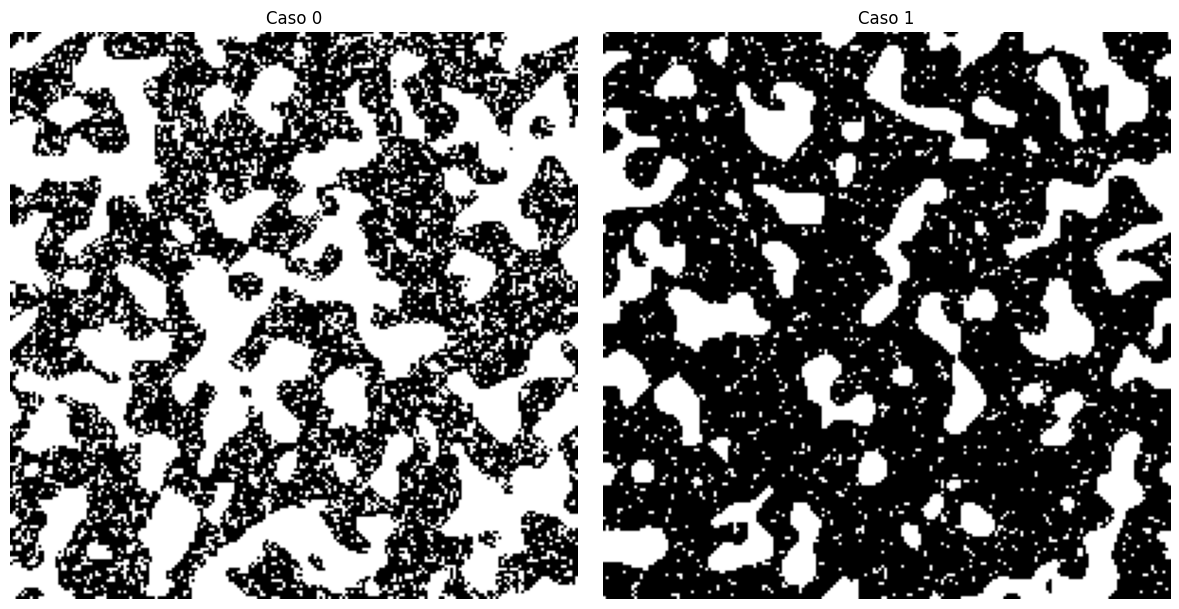

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i in range(2):
    axes[i].imshow(data["cases"][i].void, cmap="gray")
    axes[i].set_title(f"Caso {data['summaries'][i]['case_id']}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [34]:
# Carregamento da microestrutura feita por void

Ny, Nx = data["cases"][0].void.shape
print(f"Tamanho da imagem: {Ny} x {Nx}")
print(f"dtype: {data['cases'][0].void.dtype}")
print(f"Valores únicos: {np.unique(data['cases'][0].void)}")


Tamanho da imagem: 200 x 200
dtype: bool
Valores únicos: [False  True]


##### ESCALA FÍSICA DO DOMÍNIO

O domínio do Firedrake deixa de ser o quadrado unitário `[0,1]x[0,1]` e passa a ter o tamanho físico real da amostra, calculado a partir do `voxel_size_m` salvo no `.pkl`. Isso é necessário para que `K_eff` saia em unidades físicas consistentes (mesma unidade atribuída a `k_poro`/`k_solido`), em vez de um valor adimensional amarrado a um domínio de lado 1.

In [35]:

# Escala física do domínio (necessária para Keff em unidades reais)

metadata = data.get("metadata", {})

if "voxel_size_m" in metadata:
    voxel_size_m = metadata["voxel_size_m"]
    fonte_escala = "metadata do .pkl"
else:
    voxel_size_m = (40.0e-6, 40.0e-6)
    fonte_escala = "Não encontrado em metadata, ajuste manual"

print(f"voxel_size_m = {voxel_size_m}  [{fonte_escala}]")


voxel_size_m = (4e-05, 4e-05)  [metadata do .pkl]


##### CRIAÇÃO DA MALHA

In [36]:
# Malha com o tamanho FÍSICO real do domínio (Lx, Ly em metros),
# construída pela função compartilhada criar_malha() em vez de UnitSquareMesh.
malha, Lx, Ly = criar_malha(Nx, Ny, voxel_size_m)


print(f"Domínio físico: Lx = {Lx*1e3:.4f} mm, Ly = {Ly*1e3:.4f} mm")
print(f"Resolução: {Nx} x {Ny} voxels  ->  {voxel_size_m[0]*1e6:.1f} x {voxel_size_m[1]*1e6:.1f} um/voxel")

Domínio físico: Lx = 8.0000 mm, Ly = 8.0000 mm
Resolução: 200 x 200 voxels  ->  40.0 x 40.0 um/voxel


##### ESPAÇOS FUNCIONAIS


In [37]:
V_pressao = fd.FunctionSpace(malha, "CG", 1) # define o espaço de funções para a pressão
V_perm    = fd.FunctionSpace(malha, "DQ", 0) # define o espaço de funções para a permeabilidade

In [ ]:
# k_solido / k_poro: permeabilidade intrínseca (mesma unidade que sairá em Keff_x/Keff_y,
# pois Keff herda a unidade de K na homogeneização de Darcy). Se  tiverem um valor
# físico real de referência (ex.: m^2), é aqui que ele entra, a malha já está em metros
# (Lx, Ly), então o resultado final de Keff sairá fisicamente consistente.
#
# build_permeability() agora vem de pore_scale_utils.py (mesma função usada em
# validacao_solver.ipynb) -- não há mais definição duplicada aqui.
k_solido = 1e-10
k_poro = 1.0

K_fields = [
    build_permeability(case.void, V_perm, Nx, Ny, Lx, Ly, k_solido=k_solido, k_poro=k_poro)
    for case in data["cases"]
]


K = K_fields[0] if K_fields else fd.Function(V_perm, name="Permeabilidade")
print(f"Campos de permeabilidade criados: {len(K_fields)}")


######  5. VISUALIZAÇÃO DA MALHA 


In [ ]:
#fig, ax = plt.subplots(figsize=(6, 6))
#fd.triplot(malha, axes=ax)
#ax.set_title("Malha")
#plt.tight_layout()
#plt.savefig("malha.png", dpi=100)
##plt.close()
#print("Salvo: malha.png")
#

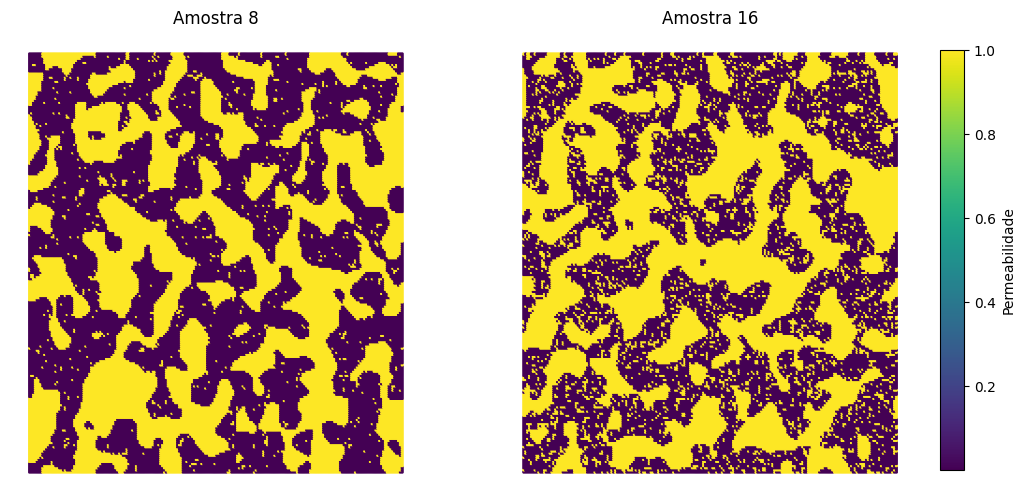

In [ ]:
import matplotlib.pyplot as plt

indices = [8, 16]  # Índices das amostras a serem visualizadas

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, idx in zip(axes, indices):
    pc = fd.tripcolor(K_fields[idx], axes=ax)
    ax.set_title(f"Amostra {idx}")
    ax.set_axis_off()

fig.subplots_adjust(right=0.88)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
fig.colorbar(pc, cax=cbar_ax, label="Permeabilidade")

plt.savefig(
    output_dir / "permeabilidadee.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#####  FORMULAÇÃO VARIACIONAL

In [ ]:
u = fd.TrialFunction(V_pressao)  # função de teste u (pressão), usada em resolver_keff abaixo
v = fd.TestFunction(V_pressao)   # função de teste v (pressão)
n = fd.FacetNormal(malha)        # vetor normal à fronteira da malha


#####  PROBLEMA NA DIREÇÃO X e Y

In [ ]:
# ============================================================
# Resolver o problema para todas as amostras (via pore_scale_utils.resolver_keff)
# ============================================================
# A lógica de solve (Direção X e Y, montagem de a/L, DirichletBC, fluxo -> Keff) agora
# vive em pore_scale_utils.py -- a mesma função usada em validacao_solver.ipynb.
# Isso elimina o risco de essas duas cópias divergirem depois de um ajuste futuro.

pressao_entrada = 1.0
pressao_saida = 0.0

resultados = []
pressures_x = []
pressures_y = []

for i, K in enumerate(K_fields):

    print(f"Resolvendo amostra {i+1}/{len(K_fields)}")

    saida = resolver_keff(
        malha, K, Lx, Ly,
        V_p=V_pressao, u=u, v=v, n=n,
        pressao_entrada=pressao_entrada,
        pressao_saida=pressao_saida,
        retornar_pressoes=True,
    )

    pressures_x.append(saida["p_x_data"])
    pressures_y.append(saida["p_y_data"])

    resultados.append(
        {
            "id": i,
            "keff_x": saida["keff_x"],
            "keff_y": saida["keff_y"],
            "porosidade_macro": data["summaries"][i]["realized_macro_porosity"],
            "porosidade_micro": data["summaries"][i]["realized_matrix_microporosity"],
            "porosidade_total": data["summaries"][i]["realized_total_porosity"],
        }
    )

print(f"\nForam resolvidas {len(resultados)} amostras em ambas as direções.")

print(f"Keff herda a mesma unidadr atribuida a k_poro/k_solido (ex.: m^2, se k_poro estiver em m^2).")


Resolvendo amostra 1/100
Resolvendo amostra 2/100
Resolvendo amostra 3/100
Resolvendo amostra 4/100
Resolvendo amostra 5/100
Resolvendo amostra 6/100
Resolvendo amostra 7/100
Resolvendo amostra 8/100
Resolvendo amostra 9/100
Resolvendo amostra 10/100
Resolvendo amostra 11/100
Resolvendo amostra 12/100
Resolvendo amostra 13/100
Resolvendo amostra 14/100
Resolvendo amostra 15/100
Resolvendo amostra 16/100
Resolvendo amostra 17/100
Resolvendo amostra 18/100
Resolvendo amostra 19/100
Resolvendo amostra 20/100
Resolvendo amostra 21/100
Resolvendo amostra 22/100
Resolvendo amostra 23/100
Resolvendo amostra 24/100
Resolvendo amostra 25/100
Resolvendo amostra 26/100
Resolvendo amostra 27/100
Resolvendo amostra 28/100
Resolvendo amostra 29/100
Resolvendo amostra 30/100
Resolvendo amostra 31/100
Resolvendo amostra 32/100
Resolvendo amostra 33/100
Resolvendo amostra 34/100
Resolvendo amostra 35/100
Resolvendo amostra 36/100
Resolvendo amostra 37/100
Resolvendo amostra 38/100
Resolvendo amostra 39

In [ ]:

pressures_x = np.array(pressures_x)
pressures_y = np.array(pressures_y)

np.save(output_dir / "pressure_x.npy", pressures_x)
np.save(output_dir / "pressure_y.npy", pressures_y)


##### VISUALIZAÇÃO DOS CAMPOS DE PRESSÃO

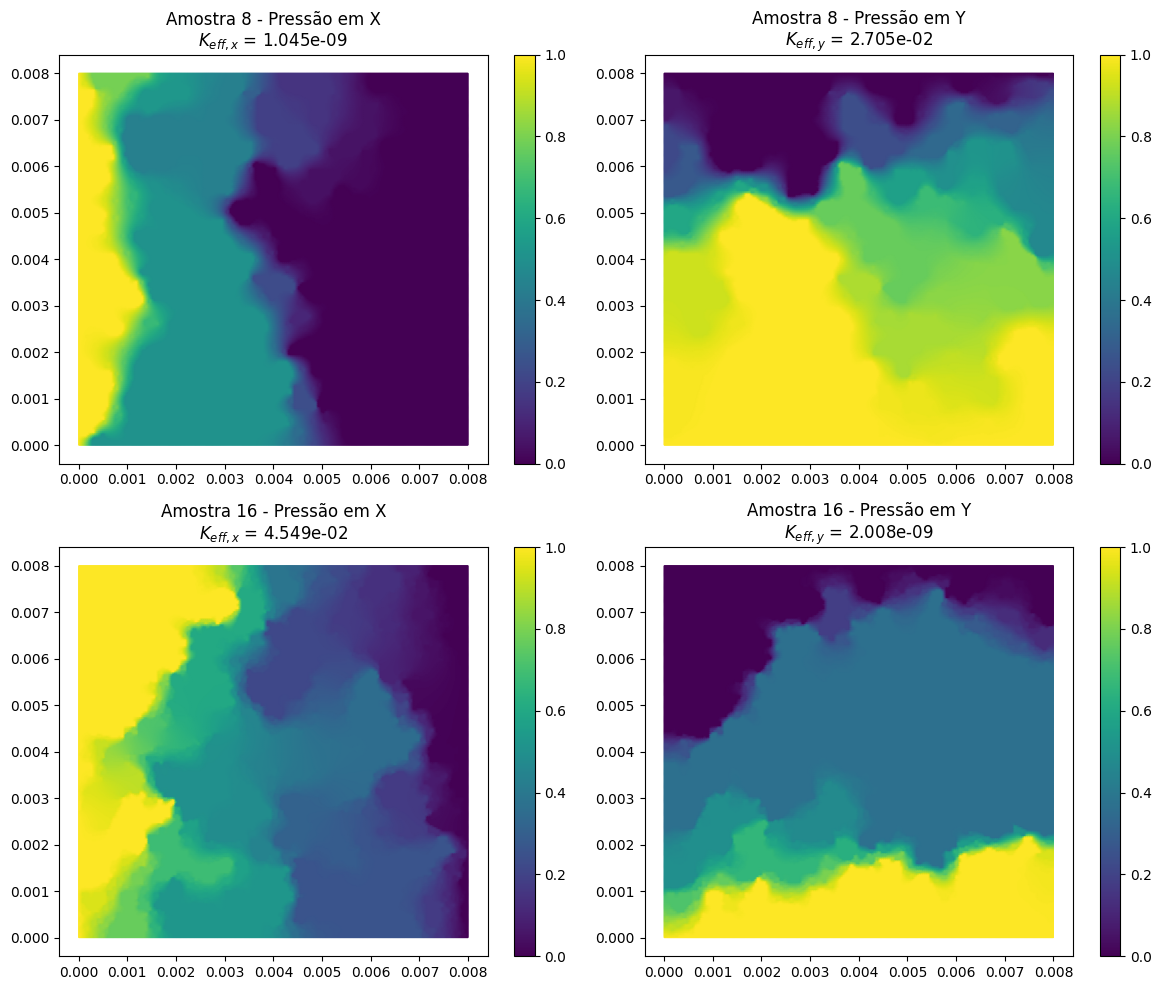

In [ ]:
indices = [8, 16]  # Amostras que serão exibidas

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, idx in enumerate(indices):

    # Reconstrói as funções de pressão
    p_x_plot = fd.Function(V_pressao)
    p_y_plot = fd.Function(V_pressao)

    p_x_plot.dat.data[:] = pressures_x[idx]
    p_y_plot.dat.data[:] = pressures_y[idx]

    # Pressão em X
    pc1 = fd.tripcolor(p_x_plot, axes=axes[row, 0])
    fig.colorbar(pc1, ax=axes[row, 0])
    axes[row, 0].set_title(
        f"Amostra {idx} - Pressão em X\n"
        f"$K_{{eff,x}}$ = {resultados[idx]['keff_x']:.3e}"
    )

    # Pressão em Y
    pc2 = fd.tripcolor(p_y_plot, axes=axes[row, 1])
    fig.colorbar(pc2, ax=axes[row, 1])
    axes[row, 1].set_title(
        f"Amostra {idx} - Pressão em Y\n"
        f"$K_{{eff,y}}$ = {resultados[idx]['keff_y']:.3e}"
    )

plt.tight_layout()

plt.savefig(
    output_dir /"pressao.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#### relação entre permeabilidade efetiva em função da porosidade total

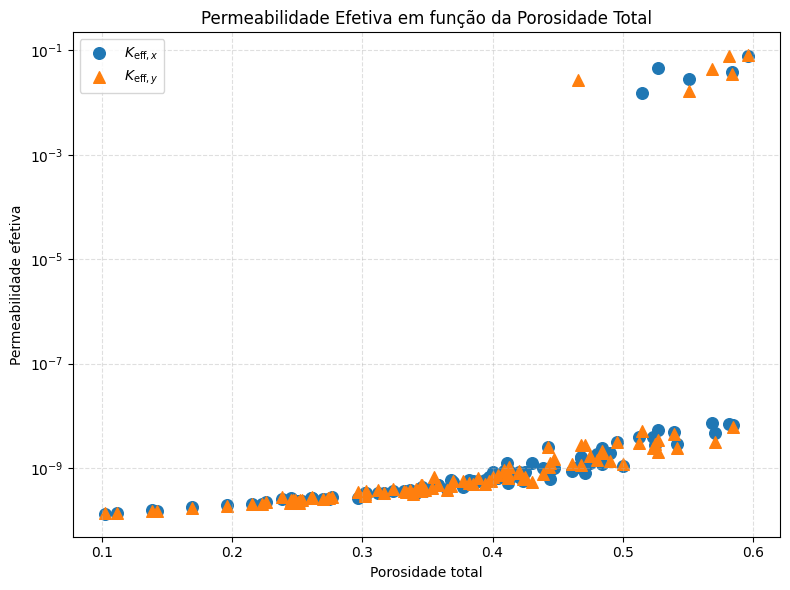

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extrai os dados
porosidade = np.array([r["porosidade_total"] for r in resultados])
keff_x = np.array([r["keff_x"] for r in resultados])
keff_y = np.array([r["keff_y"] for r in resultados])

# Figura
plt.figure(figsize=(8,6))

plt.scatter(
    porosidade,
    keff_x,
    s=70,
    marker="o",
    label=r"$K_{\mathrm{eff},x}$"
)

plt.scatter(
    porosidade,
    keff_y,
    s=70,
    marker="^",
    label=r"$K_{\mathrm{eff},y}$"
)

plt.yscale("log")

plt.xlabel("Porosidade total")
plt.ylabel("Permeabilidade efetiva")
plt.title("Permeabilidade Efetiva em função da Porosidade Total")

plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()

plt.savefig(
    output_dir / "keff_vs_porosidade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

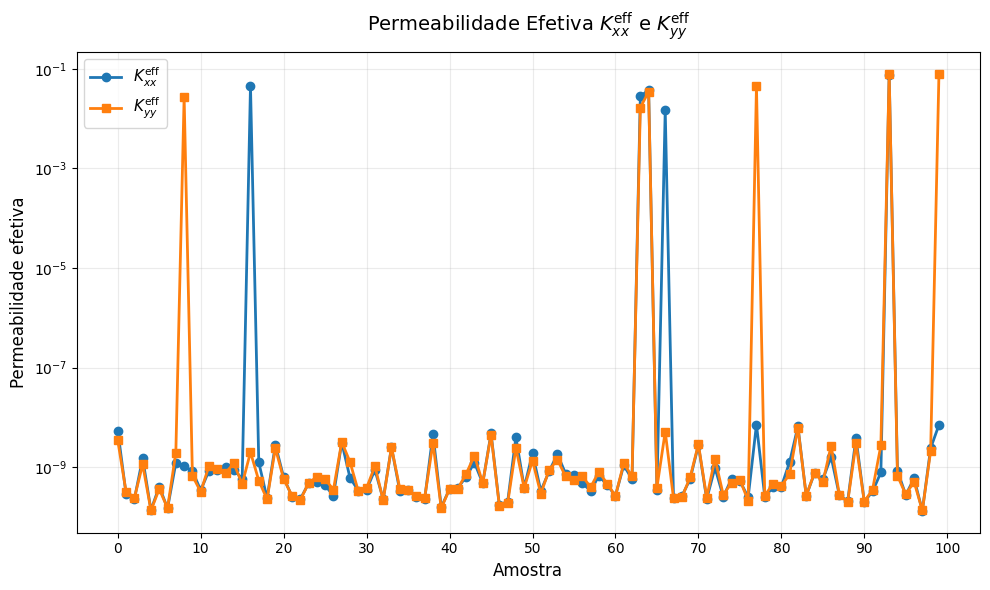

In [ ]:

ids = np.array([r["id"] for r in resultados])
keff_x = np.array([r["keff_x"] for r in resultados])
keff_y = np.array([r["keff_y"] for r in resultados])

plt.figure(figsize=(10, 6))


plt.plot(
    ids,
    keff_x,
    '-o',
    linewidth=2,
    markersize=6,
    label=r'$K_{xx}^{\mathrm{eff}}$'
)


plt.plot(
    ids,
    keff_y,
    '-s',
    linewidth=2,
    markersize=6,
    label=r'$K_{yy}^{\mathrm{eff}}$'
)


plt.yscale("log")

# Títulos e rótulos
plt.title(r"Permeabilidade Efetiva $K_{xx}^{\mathrm{eff}}$ e $K_{yy}^{\mathrm{eff}}$", fontsize=14, pad=15)
plt.xlabel("Amostra", fontsize=12)
plt.ylabel("Permeabilidade efetiva", fontsize=12)

plt.xticks(np.arange(0, 101, 10)) 

plt.grid(True, which="major", linestyle="-", alpha=0.25)
plt.grid(True, which="minor", axis="y", linestyle="--", alpha=0.1)

plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig(
    output_dir / "keff_por_amostra.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### CAMPOS DE FLUXO

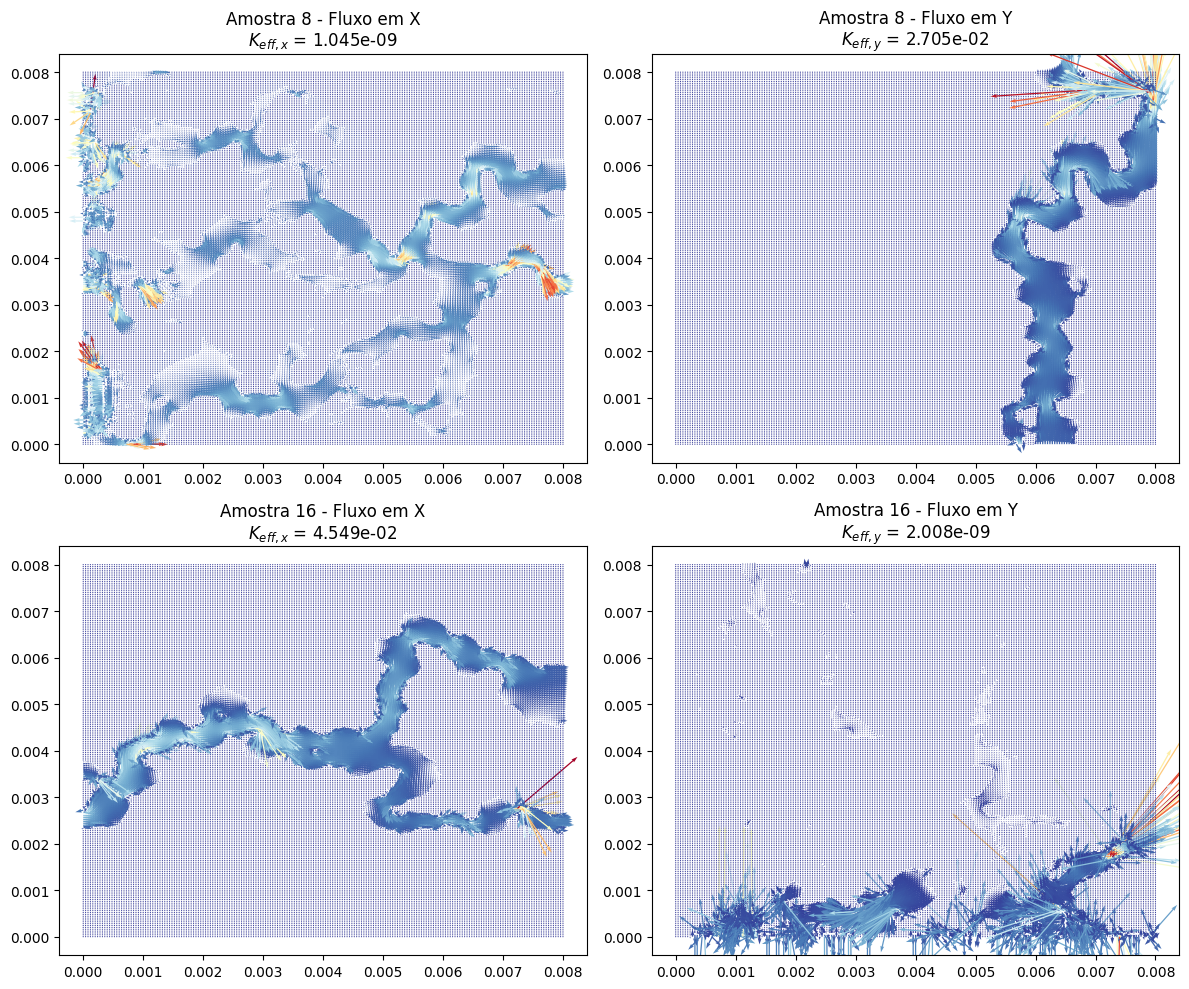

In [ ]:

indices = [8, 16]  # Amostras a serem exibidas

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, index in enumerate(indices):

    # Campo de permeabilidade da amostra
    K_case = K_fields[index]

    # Reconstrói os campos de pressão da amostra
    p_x_case = fd.Function(V_pressao, name="Pressao_X")
    p_y_case = fd.Function(V_pressao, name="Pressao_Y")

    p_x_case.dat.data[:] = pressures_x[index]
    p_y_case.dat.data[:] = pressures_y[index]

    # Fluxos de Darcy
    q_x = fd.project(
        -K_case * fd.grad(p_x_case),
        fd.VectorFunctionSpace(malha, "CG", 1),
    )

    q_y = fd.project(
        -K_case * fd.grad(p_y_case),
        fd.VectorFunctionSpace(malha, "CG", 1),
    )

    # Fluxo na direção X
    fd.quiver(q_x, axes=axes[row, 0], cmap="RdYlBu_r")
    axes[row, 0].set_title(
        f"Amostra {index} - Fluxo em X\n"
        f"$K_{{eff,x}}$ = {resultados[index]['keff_x']:.3e}"
    )

    # Fluxo na direção Y
    fd.quiver(q_y, axes=axes[row, 1], cmap="RdYlBu_r")
    axes[row, 1].set_title(
        f"Amostra {index} - Fluxo em Y\n"
        f"$K_{{eff,y}}$ = {resultados[index]['keff_y']:.3e}"
    )

plt.tight_layout()

plt.savefig(
    output_dir / "fluxo_darcy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Salvar para FNO

In [ ]:
training_data = []
for case_idx, case in enumerate(data["cases"]):
    if case_idx >= len(resultados):
        break

    # Checagem de consistência: garante que o índice usado para casar void <-> Keff
    # é de fato o mesmo case_id, e não uma reordenação acidental entre cells.
    assert resultados[case_idx]["id"] == case_idx, (
        f"Índice fora de ordem: resultados[{case_idx}]['id']={resultados[case_idx]['id']}"
    )

    sample = {
        "case_id": data["summaries"][case_idx]["case_id"],
        "input": case.void.astype(float),
        "target": {
            "K_eff_x": resultados[case_idx]["keff_x"],
            "K_eff_y": resultados[case_idx]["keff_y"],
            "units": "mesma_unidade_de_k_poro",
        },
    }
    training_data.append(sample)

output_path = "results_k_eff.pkl"
with open(output_path, "wb") as f:
    pickle.dump(training_data, f)

# Metadados globais (escala física, parâmetros usados) em arquivo separado,
# para não quebrar a estrutura de lista que as células seguintes esperam.
metadata_fno = {
    "voxel_size_m": voxel_size_m,
    "Lx_m": Lx,
    "Ly_m": Ly,
    "Nx": Nx,
    "Ny": Ny,
    "k_solido": k_solido,
    "k_poro": k_poro,
    "keff_units": "mesma_unidade_de_k_poro_k_solido",
    "n_samples": len(training_data),
}
with open("results_k_eff_metadata.json", "w") as f:
    json.dump(metadata_fno, f, indent=2)

print(f"Dataset salvo em {output_path}")
print(f"Metadados salvos em results_k_eff_metadata.json")
print(f"Total de amostras salvas: {len(training_data)}")

print(f"salvo em {output_path} e results_k_eff_metadata.json")


Dataset salvo em results_k_eff.pkl
Metadados salvos em results_k_eff_metadata.json
Total de amostras salvas: 100
salvo em results_k_eff.pkl e results_k_eff_metadata.json


# Abrir dataset

In [ ]:
import pickle

input_path = "results_k_eff.pkl"

with open(input_path, "rb") as f:
    training_data = pickle.load(f)

print(f"Total de amostras: {len(training_data)}")

Total de amostras: 100


In [ ]:
for i, sample in enumerate(training_data[:5]):
    print(f"\nAmostra {i+1}:")
    print("Case ID:", sample["case_id"])
    print("Formato da entrada:", sample["input"].shape)
    print("Keff_x:", sample["target"]["K_eff_x"])
    print("Keff_y:", sample["target"]["K_eff_y"])



Amostra 1:
Case ID: 0
Formato da entrada: (200, 200)
Keff_x: 5.456205303671871e-09
Keff_y: 3.449867526632171e-09

Amostra 2:
Case ID: 1
Formato da entrada: (200, 200)
Keff_x: 2.89504525372309e-10
Keff_y: 3.2052807005805574e-10

Amostra 3:
Case ID: 2
Formato da entrada: (200, 200)
Keff_x: 2.272381952017699e-10
Keff_y: 2.408954109064004e-10

Amostra 4:
Case ID: 3
Formato da entrada: (200, 200)
Keff_x: 1.524309618009789e-09
Keff_y: 1.1455061399295524e-09

Amostra 5:
Case ID: 4
Formato da entrada: (200, 200)
Keff_x: 1.3784179852572819e-10
Keff_y: 1.3614537364922664e-10


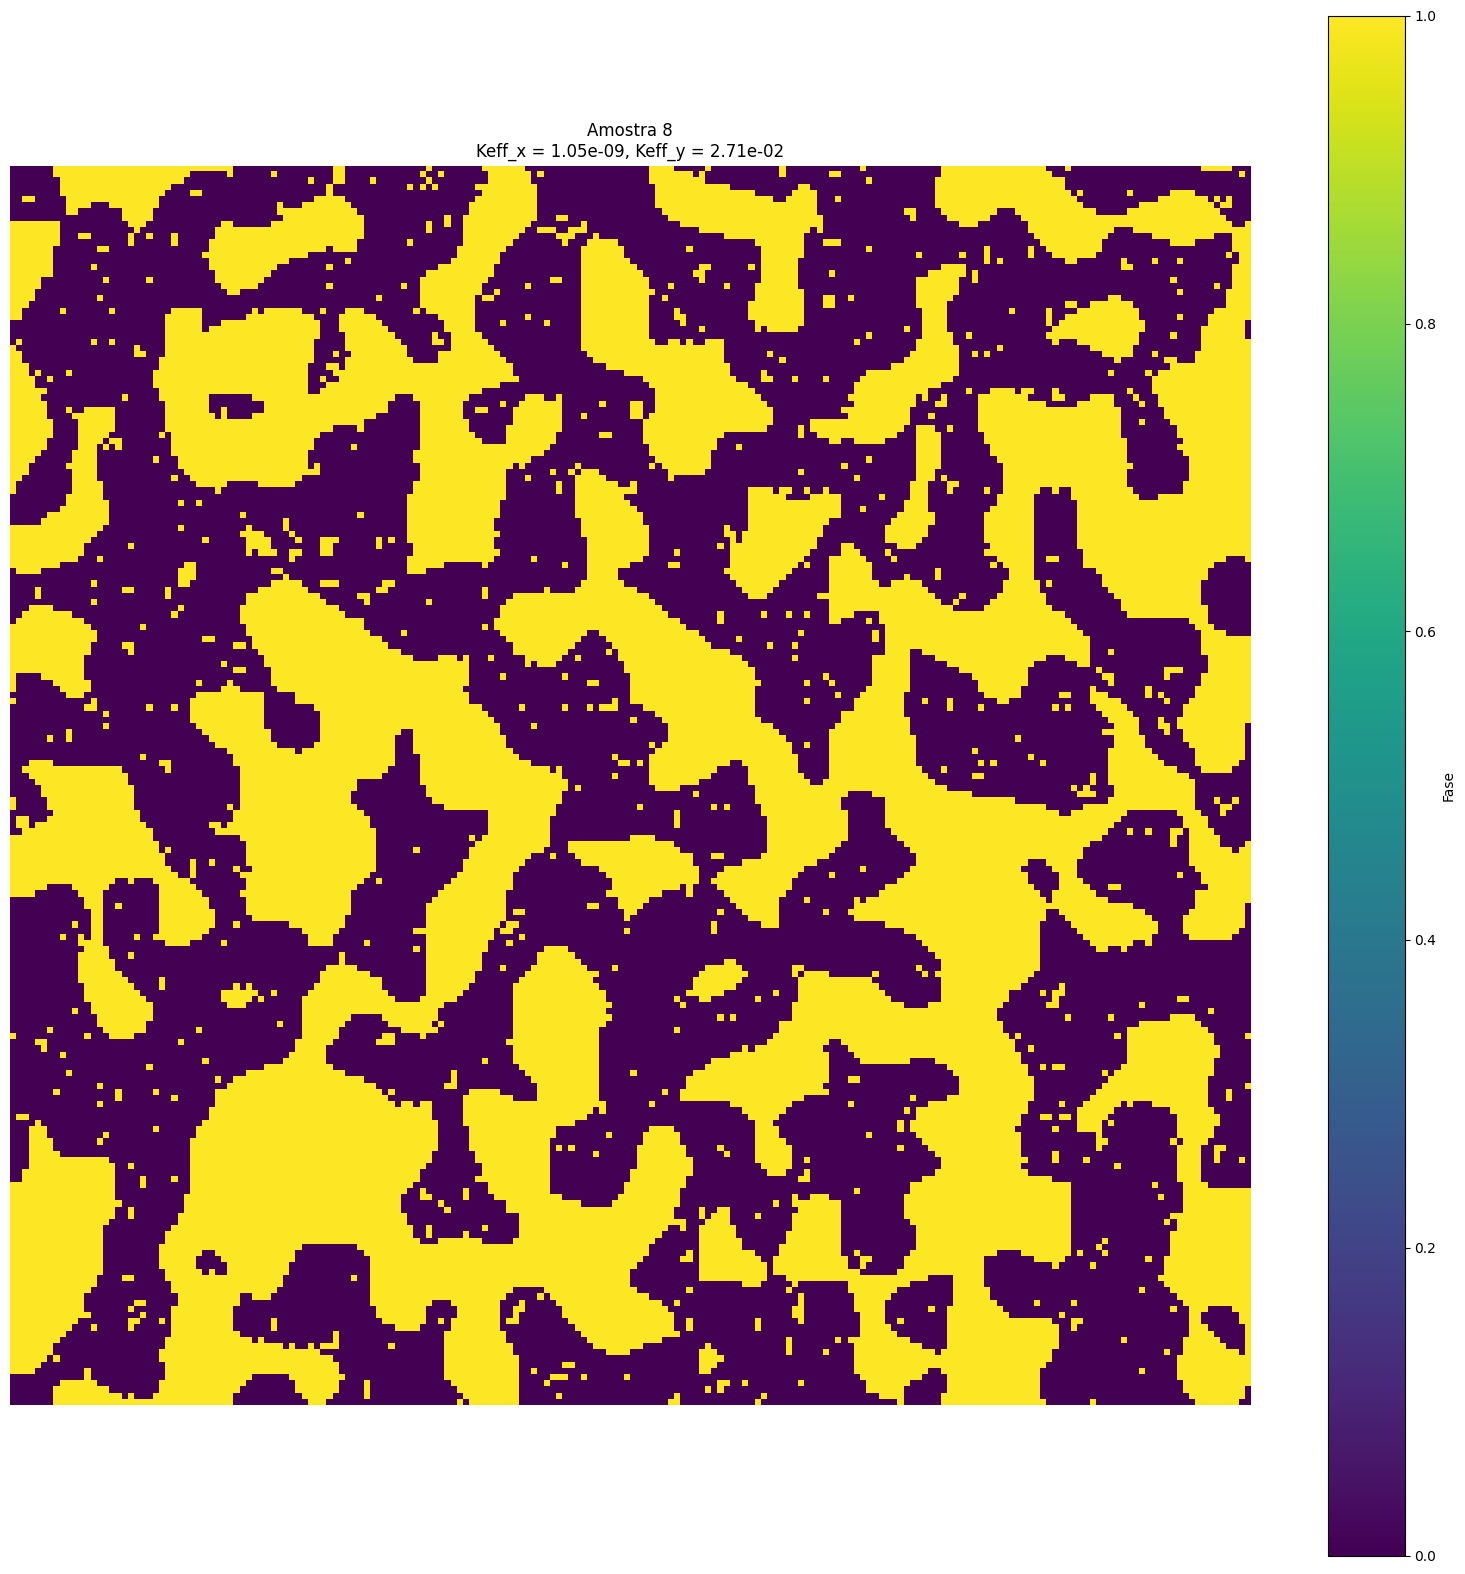

In [ ]:
idx = 8

sample = training_data[idx]
void = sample["input"]

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
plt.imshow(void, cmap="viridis")

plt.title(
    f"Amostra {idx}\n"
    f"Keff_x = {sample['target']['K_eff_x']:.2e}, "
    f"Keff_y = {sample['target']['K_eff_y']:.2e}"
)

plt.colorbar(label="Fase")
plt.axis("off")
plt.show()